In [1]:
import h5py
import glob
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# parameters used for the simulation
r_tot = 70774597466.3827
r_bot = 0.4 * r_tot
r_top = 0.9 * r_tot
Nr = 504
Ntheta = 360
Nphi = 720
dr_grid = (r_top - r_bot) / Nr

In [3]:
PATTERN= "post_checkpoints/Om0/h5file_post_1dmom.*"
all_files = sorted(glob.glob(PATTERN))

In [4]:
h5py.File(all_files[0]).keys()

<KeysViewHDF5 ['Contours', 'Grid', 'Moment_ax123', 'Moment_ax23']>

In [5]:
h5py.File(all_files[0])['Contours'].keys()

<KeysViewHDF5 ['glob_Schw_radius_envelope', 'pen_depth_conv_envelope', 'pen_depth_conv_glob_envelope', 'pen_depth_enth_envelope', 'pen_depth_enth_glob_envelope', 'pen_depth_vel_envelope', 'pen_depth_vel_glob_envelope']>

In [6]:
Schw = h5py.File(all_files[0])['Contours'].get('glob_Schw_radius_envelope')[:,:,0]
vel_env = h5py.File(all_files[0])['Contours'].get('pen_depth_vel_envelope')[:,:,0]

In [7]:
depth = (Schw - vel_env) / r_tot

In [8]:
x = np.tile(np.arange(360), (720, 1)).flatten()
y = depth.flatten()

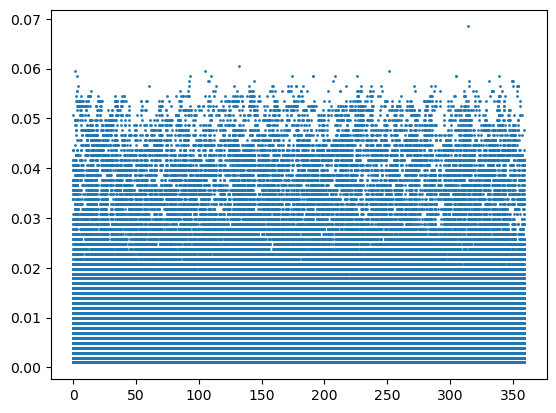

In [9]:
plt.scatter(x,y,s=1)


In [10]:
depth.shape

(720, 360)

In [11]:
depth_mean = np.mean(depth, axis=0)

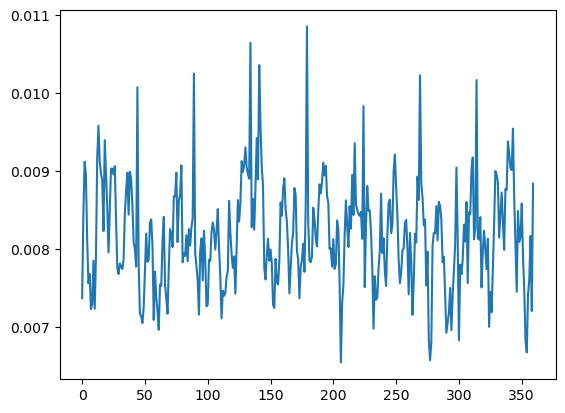

In [12]:
plt.plot(depth_mean)

In [13]:
len(all_files)

947

In [14]:
N = len(all_files) - 1
Schw = h5py.File(all_files[-N])['Contours'].get('glob_Schw_radius_envelope')[:,:,0]
vel_env = h5py.File(all_files[-N])['Contours'].get('pen_depth_vel_envelope')[:,:,0]
depth = (Schw - vel_env) / r_tot
for i in np.arange(1-N,0):
    Schw = h5py.File(all_files[i])['Contours'].get('glob_Schw_radius_envelope')[:,:,0]
    vel_env = h5py.File(all_files[i])['Contours'].get('pen_depth_vel_envelope')[:,:,0]
    temp_depth = (Schw - vel_env) / r_tot
    depth = np.dstack((depth, temp_depth))
print(depth.shape)

(720, 360, 946)


In [15]:
depth = np.mean(np.mean(depth, axis=2), axis=1)

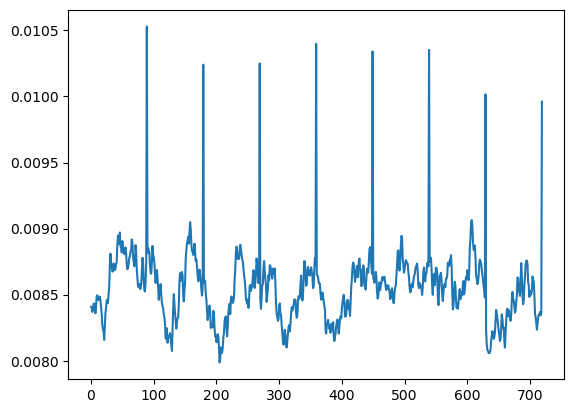

In [16]:
plt.plot(depth)

In [17]:
indices = np.argpartition(depth, -8)[-8:]

In [18]:
indices.sort()
indices

array([ 89, 179, 269, 359, 449, 539, 629, 719], dtype=int64)

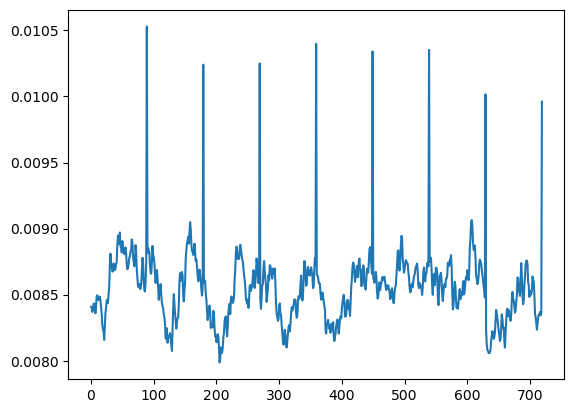

In [22]:
plt.plot(depth)
plt.savefig('Om0_depth_vs_phi.png')